## Import libraries and setup

In [1]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', None)

import holidays

target = 'load_Actual Load'


In [2]:
%pwd

'f:\\Samith\\Github\\grid-forecast\\research'

In [3]:
os.chdir("../")

In [4]:
df = pd.read_parquet("artifacts/data/power_consumption_2019_onwards.parquet")
df.head()

,load_Actual Load,wind_and_solar_forecast_Solar,wind_and_solar_forecast_Wind Offshore,wind_and_solar_forecast_Wind Onshore,intraday_wind_and_solar_forecast_Solar,intraday_wind_and_solar_forecast_Wind Offshore,intraday_wind_and_solar_forecast_Wind Onshore,generation_Biomass_Actual Aggregated,generation_Biomass_Actual Consumption,generation_Fossil Brown coal/Lignite_Actual Aggregated,generation_Fossil Brown coal/Lignite_Actual Consumption,generation_Fossil Coal-derived gas_Actual Aggregated,generation_Fossil Coal-derived gas_Actual Consumption,generation_Fossil Gas_Actual Aggregated,generation_Fossil Gas_Actual Consumption,generation_Fossil Hard coal_Actual Aggregated,generation_Fossil Hard coal_Actual Consumption,generation_Fossil Oil_Actual Aggregated,generation_Fossil Oil_Actual Consumption,generation_Geothermal_Actual Aggregated,generation_Geothermal_Actual Consumption,generation_Hydro Pumped Storage_Actual Aggregated,generation_Hydro Pumped Storage_Actual Consumption,generation_Hydro Run-of-river and poundage_Actual Aggregated,generation_Hydro Run-of-river and poundage_Actual Consumption,generation_Hydro Water Reservoir_Actual Aggregated,generation_Hydro Water Reservoir_Actual Consumption,generation_Nuclear_Actual Aggregated,generation_Nuclear_Actual Consumption,generation_Other_Actual Aggregated,generation_Other_Actual Consumption,generation_Other renewable_Actual Aggregated,generation_Other renewable_Actual Consumption,generation_Solar_Actual Aggregated,generation_Solar_Actual Consumption,generation_Waste_Actual Aggregated,generation_Waste_Actual Consumption,generation_Wind Offshore_Actual Aggregated,generation_Wind Onshore_Actual Aggregated,generation_Wind Onshore_Actual Consumption,import_CH,import_CZ,import_DK_1,import_DK_2,import_FR,import_IT_NORD,import_IT_NORD_AT,import_NL,import_PL,import_SE_4,import_SI,import_sum,generation_import_Generation_Biomass,generation_import_Generation_Fossil Brown coal/Lignite,generation_import_Generation_Fossil Coal-derived gas,generation_import_Generation_Fossil Gas,generation_import_Generation_Fossil Hard coal,generation_import_Generation_Fossil Oil,generation_import_Generation_Geothermal,generation_import_Generation_Hydro Pumped Storage,generation_import_Generation_Hydro Run-of-river and poundage,generation_import_Generation_Hydro Water Reservoir,generation_import_Generation_Nuclear,generation_import_Generation_Other,generation_import_Generation_Other renewable,generation_import_Generation_Solar,generation_import_Generation_Waste,generation_import_Generation_Wind Offshore,generation_import_Generation_Wind Onshore,generation_import_Import_CH,generation_import_Import_CZ,generation_import_Import_DK_1,generation_import_Import_DK_2,generation_import_Import_FR,generation_import_Import_IT_NORD,generation_import_Import_IT_NORD_AT,generation_import_Import_NL,generation_import_Import_PL,generation_import_Import_SE_4,generation_import_Import_SI,generation_import_Import_sum,import_BE,generation_import_Import_BE,import_AT,generation_import_Import_AT,import_NO_2,generation_import_Import_NO_2,hour,minute,time_of_day,month,day_of_week,year,is_weekend
2019-01-01 00:00:00+01:00,44461.48,0.0,5042.14,18224.16,0.0,3985.90,18598.02,4739.80,NaN,6932.07,NaN,273.0,NaN,3410.34,0.78,3345.27,NaN,482.04,NaN,21.53,NaN,353.43,1732.01,1485.29,NaN,128.06,NaN,9001.69,NaN,475.20,NaN,113.72,NaN,0.12,NaN,783.29,NaN,3176.52,19308.92,NaN,595.29,884.56,0.0,364.60,0.0,NaN,NaN,0.0,0.0,74.7,NaN,1963.02,4739.80,6932.07,273.0,3409.56,3345.27,482.04,21.53,-1378.58,1485.29,128.06,9001.69,475.20,113.72,0.12,783.29,3176.52,19308.92,595.29,884.56,0.0,364.60,0.0,NaN,NaN,0.0,0.0,74.7,NaN,1963.02,0.00,0.00,43.87,43.87,NaN,NaN,0,0,0.00,1,1,2019,False
2019-01-01 00:15:00+01:00,43913.65,0.0,5060.99,18652.06,0.0,3877.54,19170.96,4744.73,NaN,6351.45,NaN,481.1,NaN,3294.88,0.78,2917.81,NaN,483.70,NaN,21.66,NaN,400.52,1120.19,1484.14,NaN,103.77,NaN,9053.14,NaN,474.70,NaN,114.04,NaN,0.13,NaN,771.76,NaN,3174.16,20030.02,NaN,NaN,NaN,NaN,NaN,NaN,N

In [5]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 249726 entries, 2019-01-01 00:00:00+01:00 to 2026-02-23 00:30:00+01:00
Data columns (total 94 columns):
 #   Column                                                         Non-Null Count   Dtype  
---  ------                                                         --------------   -----  
 0   load_Actual Load                                               249726 non-null  float64
 1   wind_and_solar_forecast_Solar                                  249714 non-null  float64
 2   wind_and_solar_forecast_Wind Offshore                          249726 non-null  float64
 3   wind_and_solar_forecast_Wind Onshore                           249714 non-null  float64
 4   intraday_wind_and_solar_forecast_Solar                         249726 non-null  float64
 5   intraday_wind_and_solar_forecast_Wind Offshore                 249726 non-null  float64
 6   intraday_wind_and_solar_forecast_Wind Onshore                  249726 non-null  float64
 7   generation_B

In [6]:
df.index.min(), df.index.max()

(Timestamp('2019-01-01 00:00:00+0100', tz='Europe/Berlin'),
 Timestamp('2026-02-23 00:30:00+0100', tz='Europe/Berlin'))

In [7]:
df['load_Actual Load'].isnull().sum()

np.int64(0)

In [8]:
missing = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_pct": (df.isnull().sum() / len(df) * 100).round(2),
    "present_count": df.notnull().sum(),
})
missing = missing.sort_values("missing_pct", ascending=False)
missing = missing[missing["missing_pct"]>0]
missing

,missing_count,missing_pct,present_count
generation_Fossil Brown coal/Lignite_Actual Consumption,249726,100.00,0
generation_Biomass_Actual Consumption,249726,100.00,0
generation_Fossil Coal-derived gas_Actual Consumption,249726,100.00,0
generation_Hydro Run-of-river and poundage_Actual Consumption,249726,100.00,0
generation_Geothermal_Actual Consumption,249726,100.00,0
generation_Fossil Hard coal_Actual Consumption,249726,100.00,0
generation_import_Import_IT_NORD,249726,100.00,0
generation_import_Import_IT_NORD_AT,249726,100.00,0
import_IT_NORD_AT,249726,100.00,0
import_SI,249726,100.00,0


In [9]:
df.shape

(249726, 94)

### Drop the columns with 40 % missing rate

In [10]:
threshold = 0.40
cols_to_drop = df[df.columns[df.isnull().mean() > threshold]].columns
df.drop(columns=cols_to_drop, inplace=True)
df.shape

(249726, 69)

In [11]:
df.isnull().sum().sort_values(ascending=False)

generation_Nuclear_Actual Aggregated          99766
generation_Solar_Actual Consumption           95643
generation_Wind Onshore_Actual Consumption    95643
generation_import_Generation_Nuclear          74895
import_CH                                     67828
                                              ...  
time_of_day                                       0
month                                             0
day_of_week                                       0
year                                              0
is_weekend                                        0
Length: 69, dtype: int64

### For remaining columns with <40% missing, interpolate

In [12]:
for col in df.columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].interpolate(method='time', limit=None)

In [13]:
df.shape

(249726, 69)

In [14]:
print(df.isnull().sum().sum())

263252


In [15]:
print("NaNs remaining after interpolation:")
print(df.isnull().sum()[df.isnull().sum() > 0])

print(f"\nTotal rows before feature engineering: {len(df)}")

NaNs remaining after interpolation:
generation_Solar_Actual Consumption           73163
generation_Wind Onshore_Actual Consumption    73163
import_NO_2                                   58463
generation_import_Import_NO_2                 58463
dtype: int64

Total rows before feature engineering: 249726


In [16]:
print("Solar NaN locations:")
solar_nulls = df['generation_Solar_Actual Consumption'].isnull()
print(f"  First NaN: {df[solar_nulls].index[0]}")
print(f"  Last NaN: {df[solar_nulls].index[-1]}")

print("\nWind_Onshore_nulls NaN locations:")
Wind_Onshore_nulls = df['generation_Wind Onshore_Actual Consumption'].isnull()
print(f"  First NaN: {df[Wind_Onshore_nulls].index[0]}")
print(f"  Last NaN: {df[Wind_Onshore_nulls].index[-1]}")

print("\nimport_NO_2 NaN locations:")
no2_nulls = df['import_NO_2'].isnull()
print(f"  First NaN: {df[no2_nulls].index[0]}")
print(f"  Last NaN: {df[no2_nulls].index[-1]}")

print("\ngeneration_import_Import_NO_2 NaN locations:")
import_no2_nulls = df['generation_import_Import_NO_2'].isnull()
print(f"  First NaN: {df[import_no2_nulls].index[0]}")
print(f"  Last NaN: {df[import_no2_nulls].index[-1]}")

Solar NaN locations:
  First NaN: 2019-01-01 00:00:00+01:00
  Last NaN: 2021-02-03 01:00:00+01:00

Wind_Onshore_nulls NaN locations:
  First NaN: 2019-01-01 00:00:00+01:00
  Last NaN: 2021-02-03 01:00:00+01:00

import_NO_2 NaN locations:
  First NaN: 2019-01-01 00:00:00+01:00
  Last NaN: 2020-09-01 23:45:00+02:00

generation_import_Import_NO_2 NaN locations:
  First NaN: 2019-01-01 00:00:00+01:00
  Last NaN: 2020-09-01 23:45:00+02:00


In [17]:
drop_cols = [
    'generation_Solar_Actual Consumption',
    'generation_Wind Onshore_Actual Consumption',
    'import_NO_2',
    'generation_import_Import_NO_2'
]
df.drop(columns=drop_cols, inplace=True)

In [18]:
print(df.isnull().sum().sum())  
print(df.shape) 

0
(249726, 65)


In [19]:
def feature_engineering(df):
    df['quarter'] = df.index.quarter
    df['day_of_year'] = df.index.dayofyear
    df['week_of_year'] = df.index.isocalendar().week.astype(int)

    # Hour
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

    # Day of week
    df['dow_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
    df['dow_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

    # Month
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

    de_holidays = holidays.Germany(years=range(2019, 2027))

 
    df_dates = df.index.date  

    df['is_holiday'] = pd.Series([d in de_holidays for d in df_dates], index=df.index).astype(int)

    df['is_holiday_eve'] = pd.Series([(d - pd.Timedelta(days=1).to_pytimedelta()) in de_holidays for d in df_dates],index=df.index).astype(int)

    
    # Previous day same time
    df['lag_96']  = df[target].shift(96)   # 1 day ago

    # Previous 2 days
    df['lag_192'] = df[target].shift(192)  # 2 days ago

    # Previous week same time — usually strongest single lag
    df['lag_672'] = df[target].shift(672)  # 1 week ago

    # Previous 2 weeks
    df['lag_1344'] = df[target].shift(1344) # 2 weeks ago

    # Recent lags (last few 15-min intervals)
    df['lag_1'] = df[target].shift(1)   # 15 mins ago
    df['lag_4'] = df[target].shift(4)   # 1 hour ago
    df['lag_8'] = df[target].shift(8)   # 2 hours ago


    # Shift by 96 first to avoid data leakage
    df['rolling_mean_24h'] = df[target].shift(96).rolling(96).mean()
    df['rolling_std_24h']  = df[target].shift(96).rolling(96).std()
    df['rolling_min_24h']  = df[target].shift(96).rolling(96).min()
    df['rolling_max_24h']  = df[target].shift(96).rolling(96).max()

    df['rolling_mean_7d']  = df[target].shift(96).rolling(672).mean()
    df['rolling_std_7d']   = df[target].shift(96).rolling(672).std()


    # Hour x weekend interaction
    df['hour_x_weekend'] = df['hour'] * df['is_weekend']

    # Hour x month interaction (captures seasonal intraday patterns)
    df['hour_x_month'] = df['hour'] * df['month']

    gen_cols = [
    'generation_Nuclear_Actual Aggregated',	
    'generation_import_Generation_Nuclear',
    'import_CH',
    'import_NL',
    'import_AT',
    'import_DK_1',
    'import_DK_2',
    'generation_Hydro Water Reservoir_Actual Aggregated',
    'generation_Waste_Actual Aggregated'
    ]

    # Lag these too to avoid leakage
    for col in gen_cols:
        df[f'{col}_lag_96'] = df[col].shift(96)


    df.dropna(inplace=True)

    return df

In [20]:
feature_engineering(df)
df.shape

(248382, 100)

In [21]:
%pwd

'f:\\Samith\\Github\\grid-forecast'

In [22]:
df.to_parquet('artifacts/data/df_features.parquet')

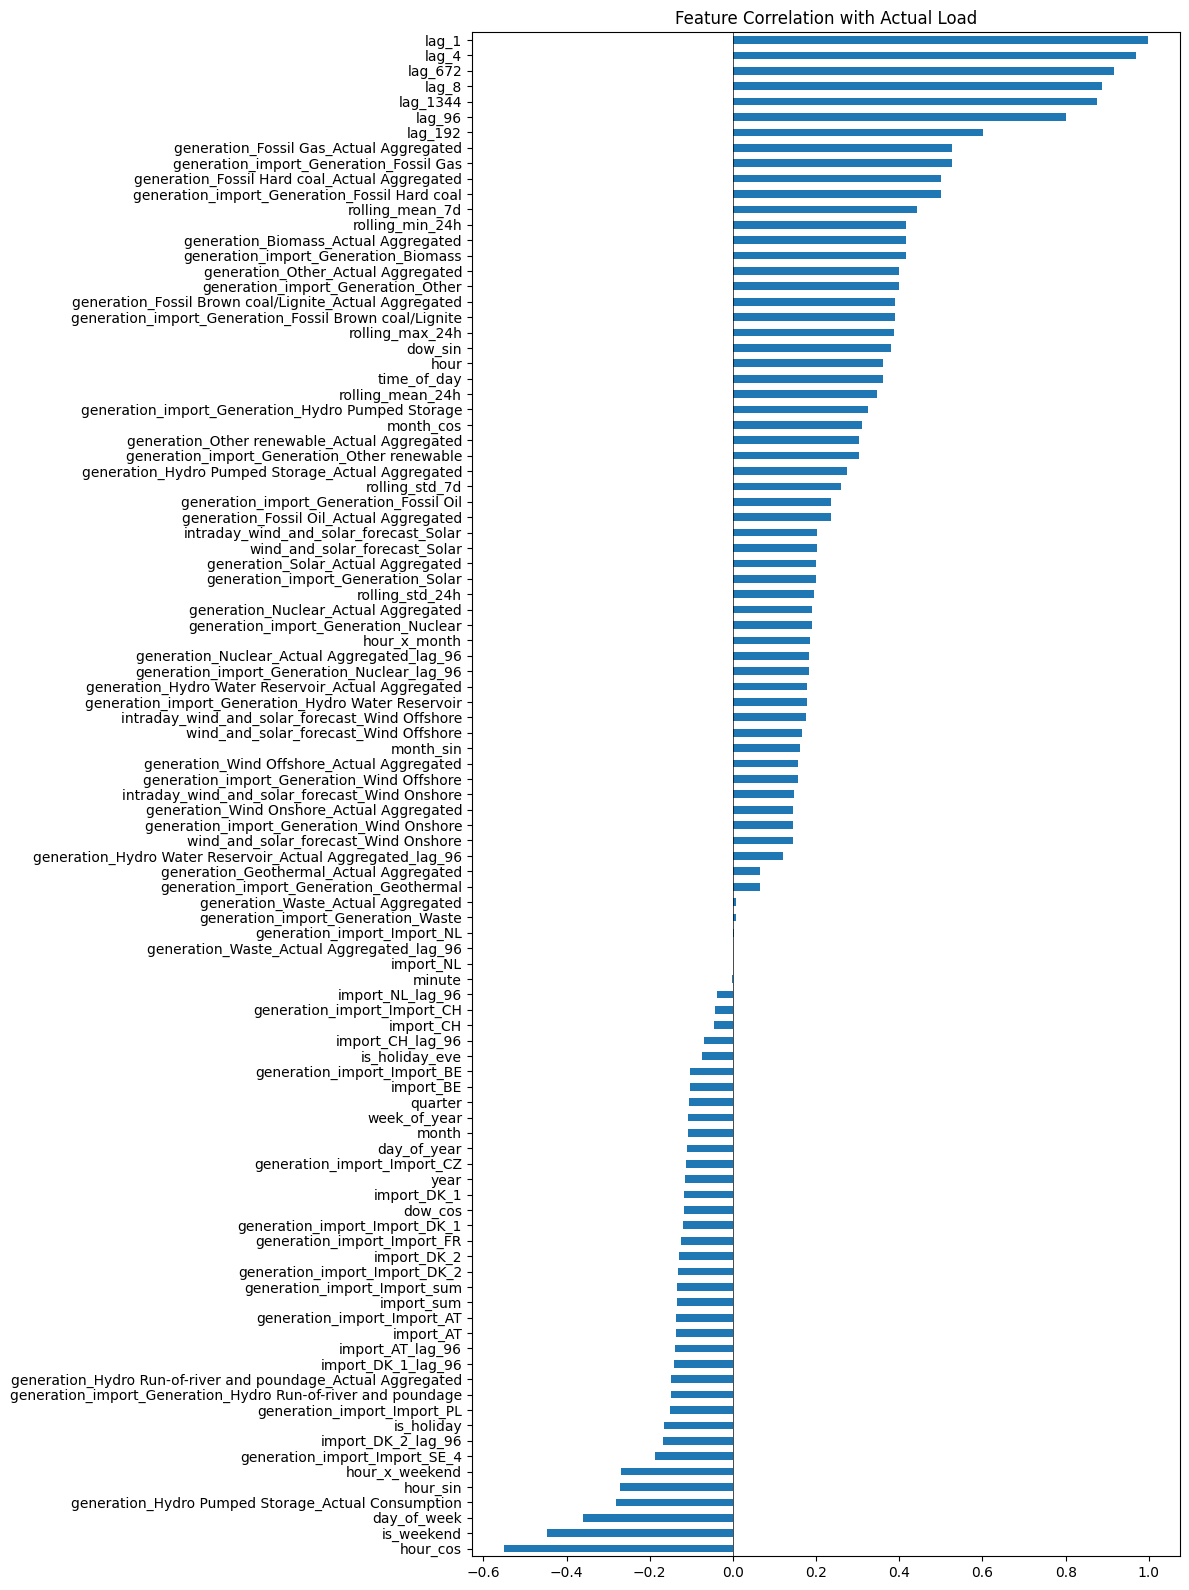

Top 10 positively correlated:
generation_Fossil Hard coal_Actual Aggregated    0.501176
generation_import_Generation_Fossil Gas          0.526299
generation_Fossil Gas_Actual Aggregated          0.526305
lag_192                                          0.602068
lag_96                                           0.801869
lag_1344                                         0.875286
lag_8                                            0.888042
lag_672                                          0.915188
lag_4                                            0.968601
lag_1                                            0.997599
Name: load_Actual Load, dtype: float64

Top 10 negatively correlated:
hour_cos                                             -0.550364
is_weekend                                           -0.446144
day_of_week                                          -0.360158
generation_Hydro Pumped Storage_Actual Consumption   -0.281767
hour_sin                                             -0.272124
hour_

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation of all features with target
corr = df.corr()[target].drop(target).sort_values()

plt.figure(figsize=(12, 16))
corr.plot(kind='barh', figsize=(12, 16))
plt.title('Feature Correlation with Actual Load')
plt.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

# Print top and bottom correlators
print("Top 10 positively correlated:")
print(corr.tail(10))
print("\nTop 10 negatively correlated:")
print(corr.head(10))

In [24]:
corr_full = df.corr()[target].drop(target).dropna().sort_values()

# Feature strength summary
print(f"Total features: {len(corr_full)}")
print(f"Strong (>0.3 abs):   {(corr_full.abs() > 0.3).sum()}")
print(f"Moderate (0.1-0.3):  {((corr_full.abs() >= 0.1) & (corr_full.abs() <= 0.3)).sum()}")
print(f"Weak (<0.1 abs):     {(corr_full.abs() < 0.1).sum()}")

# Weak features — candidates to drop
weak = corr_full[corr_full.abs() < 0.05]
print(f"\nVery weak features (<0.05 correlation):")
print(weak)

Total features: 99
Strong (>0.3 abs):   31
Moderate (0.1-0.3):  55
Weak (<0.1 abs):     13

Very weak features (<0.05 correlation):
import_CH                                   -0.045037
generation_import_Import_CH                 -0.043410
import_NL_lag_96                            -0.038300
minute                                      -0.002247
import_NL                                   -0.000945
generation_Waste_Actual Aggregated_lag_96   -0.000367
generation_import_Import_NL                  0.002963
generation_import_Generation_Waste           0.007921
generation_Waste_Actual Aggregated           0.008576
Name: load_Actual Load, dtype: float64


In [25]:
weak_all = corr_full[corr_full.abs() < 0.1].sort_values()
print("All weak features (<0.1 correlation):")
print(weak_all)

All weak features (<0.1 correlation):
is_holiday_eve                              -0.073239
import_CH_lag_96                            -0.068863
import_CH                                   -0.045037
generation_import_Import_CH                 -0.043410
import_NL_lag_96                            -0.038300
minute                                      -0.002247
import_NL                                   -0.000945
generation_Waste_Actual Aggregated_lag_96   -0.000367
generation_import_Import_NL                  0.002963
generation_import_Generation_Waste           0.007921
generation_Waste_Actual Aggregated           0.008576
generation_import_Generation_Geothermal      0.065118
generation_Geothermal_Actual Aggregated      0.065145
Name: load_Actual Load, dtype: float64


In [26]:
drop_features = [
    'minute',
    'import_NL',
    'import_NL_lag_96',
    'import_CH',
    'import_CH_lag_96',
    'generation_import_Import_CH',
    'generation_import_Import_NL',
    'generation_Waste_Actual Aggregated',
    'generation_Waste_Actual Aggregated_lag_96',
    'generation_import_Generation_Waste',
    'generation_Geothermal_Actual Aggregated',
    'generation_import_Generation_Geothermal',
]

df.drop(columns=drop_features, inplace=True)
print(f"Final features: {df.shape[1]}")

Final features: 88


In [27]:
%pwd

'f:\\Samith\\Github\\grid-forecast'

In [28]:
output_dir = 'artifacts/preprocessed'
os.makedirs(output_dir, exist_ok=True)

df.to_parquet(output_dir + '/power_consumption_preprocessed.parquet') 